# Histogramme

Taille histogramme : (4096,)
Somme : 1.0


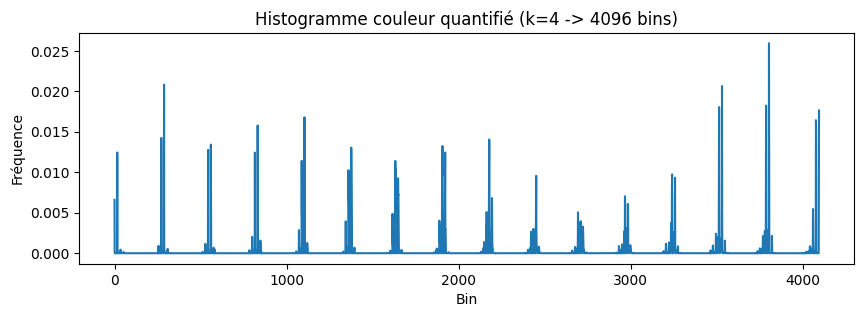

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def color_hist_quantized(image_path, k=4, normalize=True):
    img = Image.open(image_path).convert("RGB")
    arr = np.array(img, dtype=np.uint8)

    levels = 2**k  # ex: 16

    # Convertir en int pour éviter overflow
    arr = arr.astype(np.int32)

    # Quantification 0..255 -> 0..levels-1
    q = (arr * levels) // 256

    # Index unique
    idx = (q[..., 0] * (levels**2) + q[..., 1] * levels + q[..., 2]).ravel()

    hist = np.bincount(idx, minlength=levels**3).astype(np.float32)

    if normalize:
        hist /= hist.sum() + 1e-12

    return hist

# Exemple
image_path = "mon_image.jpg"
hist = color_hist_quantized(image_path, k=4)

print("Taille histogramme :", hist.shape)  # (4096,)
print("Somme :", hist.sum())

plt.figure(figsize=(10,3))
plt.plot(hist)
plt.title("Histogramme couleur quantifié (k=4 -> 4096 bins)")
plt.xlabel("Bin")
plt.ylabel("Fréquence")
plt.show()


In [ ]:
print(hist)
print(hist.shape)

[6.5956116e-03 2.0408630e-04 0.0000000e+00 ... 6.8664551e-05 9.7878771e-03
 1.7637253e-02]
(4096,)


# Extraction de contours:

**Extraction de contours avec Sobel (gradient)**

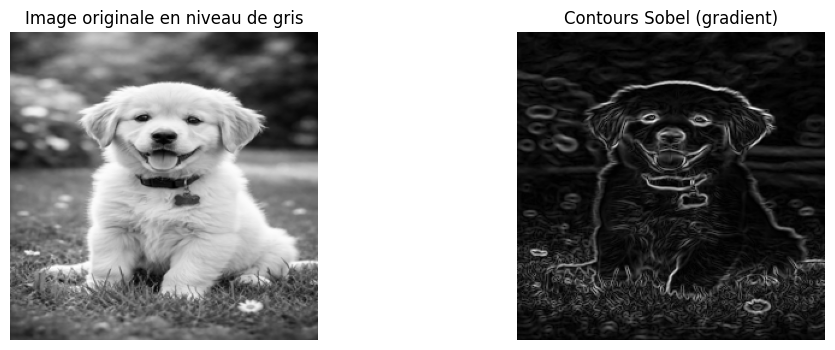

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import sobel

# Charger image en niveaux de gris
img = Image.open("mon_image.jpg").convert("L")# L pour passer de RGB (3 canaux) à une image en niveaux de gris
img = img.resize((256, 256))  # optionnel, style de standardisation pour avoir la meme taille pour toutes les images
I = np.array(img) / 255.0     # normalisation [0,1]

# Sobel = magnitude du gradient
edges_sobel = sobel(I)

# Affichage
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(I, cmap="gray")
plt.title("Image originale en niveau de gris")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges_sobel, cmap="gray")
plt.title("Contours Sobel (gradient)")
plt.axis("off")

plt.show()


**Sobel apres seuillage**

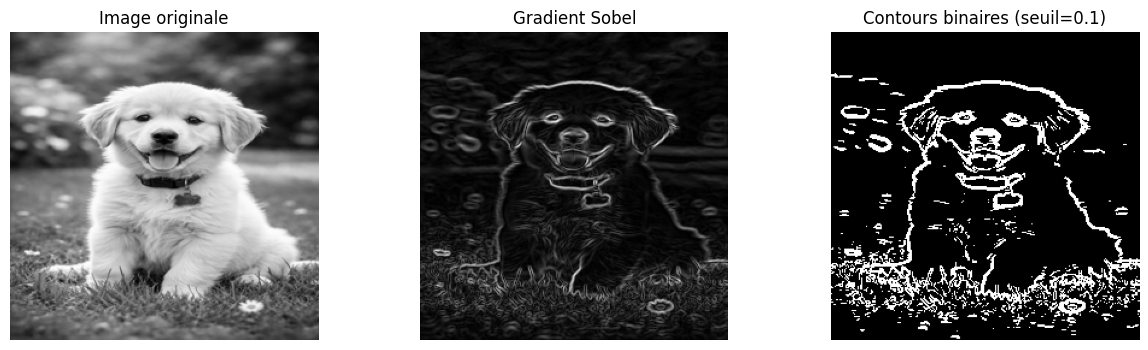

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.filters import sobel

img = Image.open("mon_image.jpg").convert("L")
img = img.resize((256, 256))
I = np.array(img) / 255.0

# Gradient Sobel
G = sobel(I)

# Seuillage simple
threshold = 0.1
binary_edges = (G > threshold)
#Si un pixel a un gradient supérieur au seuil il est True donc blanc = contour (1)
#sinon il est False donc noir = pas contour (0)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(I, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="gray")
plt.title("Gradient Sobel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(binary_edges, cmap="gray")
plt.title(f"Contours binaires (seuil={threshold})")
plt.axis("off")

plt.show()


**Extraction de contours avec Canny**

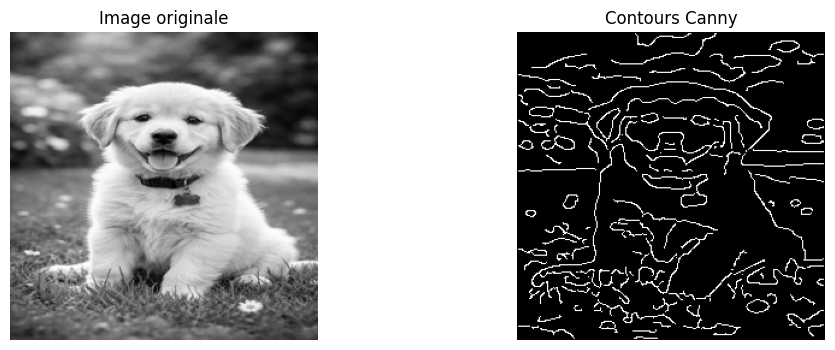

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import canny

# Charger image en niveaux de gris
img = Image.open("mon_image.jpg").convert("L")
img = img.resize((256, 256))  # optionnel
I = np.array(img) / 255.0

# Canny
edges_canny = canny(I, sigma=2)

# Affichage
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(I, cmap="gray")
plt.title("Image originale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges_canny, cmap="gray")
plt.title("Contours Canny")
plt.axis("off")

plt.show()


# Extraction de Coins  

**Coins Harris**

Nombre de coins détectés : 77


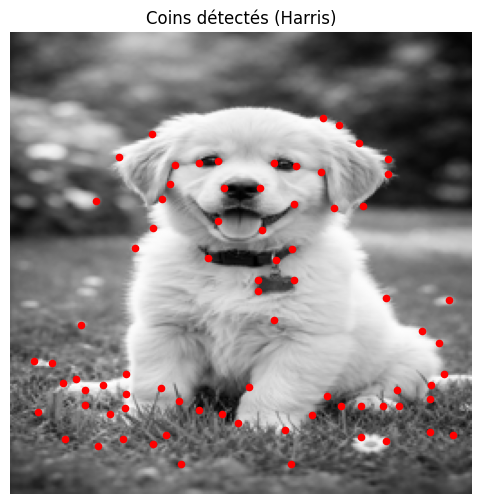

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import corner_harris, corner_peaks

# Charger image en niveaux de gris
img = Image.open("mon_image.jpg").convert("L").resize((256, 256))
I = np.array(img) / 255.0

# Harris response
H = corner_harris(I, method="k", k=0.04, sigma=1.5)

# Extraire les coins (pics)
coords = corner_peaks(H, min_distance=5, threshold_rel=0.02)

print("Nombre de coins détectés :", len(coords))

# Affichage
plt.figure(figsize=(6,6))
plt.imshow(I, cmap="gray")
plt.scatter(coords[:, 1], coords[:, 0], s=20, c="red")
plt.title("Coins détectés (Harris)")
plt.axis("off")
plt.show()


**Coins par Shi–Tomasi**

Nombre de coins détectés : 190


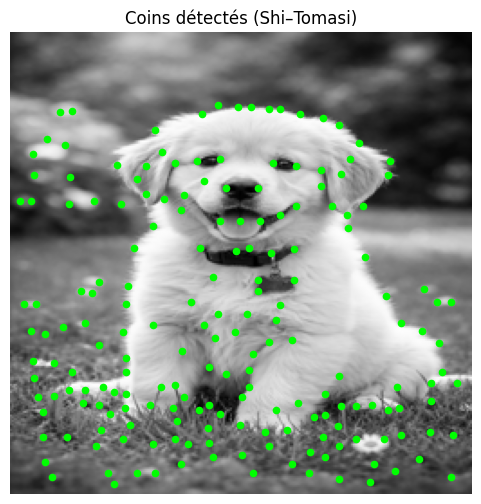

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import corner_shi_tomasi, corner_peaks

img = Image.open("mon_image.jpg").convert("L").resize((256, 256))
I = np.array(img) / 255.0

S = corner_shi_tomasi(I)
coords = corner_peaks(S, min_distance=5, threshold_rel=0.02)

print("Nombre de coins détectés :", len(coords))

plt.figure(figsize=(6,6))
plt.imshow(I, cmap="gray")
plt.scatter(coords[:, 1], coords[:, 0], s=20, c="lime")
plt.title("Coins détectés (Shi–Tomasi)")
plt.axis("off")
plt.show()


# Points d'interet avec SIFT

**Détection + affichage des keypoints SIFT**

Une image génère une matrice (pas un seul vecteur):
- lignes = points clés
- colonnes = caractéristiques du descripteur SIFT

On doit transformer cette matrice en un vecteur fixe par :

- moyenne des descripteurs (128)
- Bag of Visual Words (BoVW)
- VLAD / Fisher Vector


In [17]:
pip install opencv-contrib-python


Nombre de points clés détectés : 4142
Taille des descripteurs : (4142, 128)


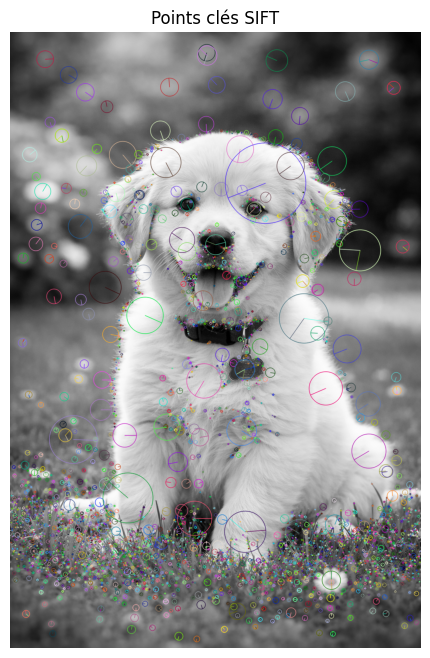

In [18]:
import cv2
import matplotlib.pyplot as plt

# Charger l'image en niveaux de gris
img = cv2.imread("mon_image.jpg", cv2.IMREAD_GRAYSCALE)

# Créer l'objet SIFT
sift = cv2.SIFT_create()

# Détecter keypoints + descripteurs
keypoints, descriptors = sift.detectAndCompute(img, None)

print("Nombre de points clés détectés :", len(keypoints))
print("Taille des descripteurs :", descriptors.shape)  # (nb_points, 128)

# Dessiner les keypoints
img_kp = cv2.drawKeypoints(img, keypoints, None,
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Affichage
plt.figure(figsize=(8,8))
plt.imshow(img_kp, cmap="gray")
plt.title("Points clés SIFT")
plt.axis("off")
plt.show()


# Extraction des régions

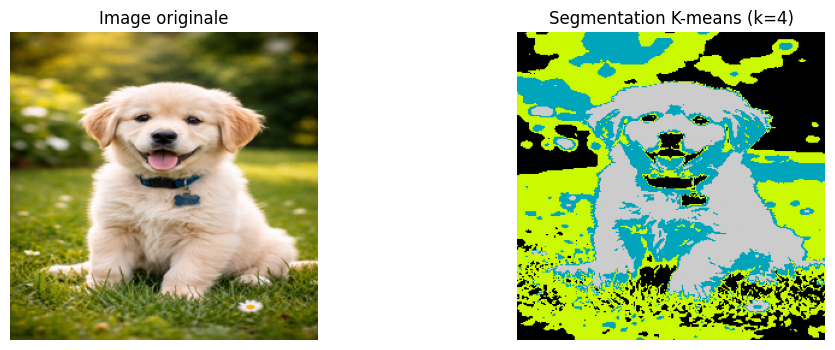

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

# 1) Charger l'image couleur
img = Image.open("mon_image.jpg").convert("RGB")
img = img.resize((256, 256))  # optionnel
I = np.array(img)

# 2) Transformer l'image en matrice (N pixels, 3)
X = I.reshape(-1, 3)

# 3) K-means clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# 4) Reconstruire l'image segmentée
segmented = labels.reshape(I.shape[0], I.shape[1])

# 5) Affichage
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(I)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap="nipy_spectral")
plt.title(f"Segmentation K-means (k={k})")
plt.axis("off")

plt.show()


IMage recolorée par les labels de centre de Kmeans

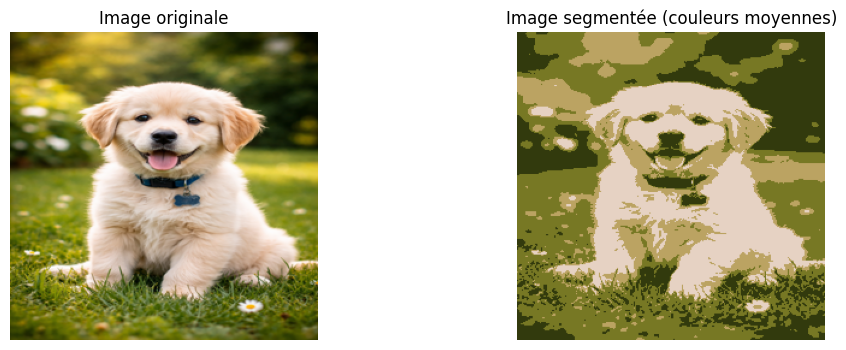

In [25]:
# Recoloration avec les centres
centers = kmeans.cluster_centers_.astype(np.uint8)
segmented_img = centers[labels].reshape(I.shape)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(I)
plt.title("Image originale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented_img)
plt.title("Image segmentée (couleurs moyennes)")
plt.axis("off")
plt.show()
